In [71]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

In [72]:
df = pd.read_csv('data\project1_df.csv')

<>:1: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:1: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
C:\Users\Daryna\AppData\Local\Temp\ipykernel_16724\2209859016.py:1: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
  df = pd.read_csv('data\project1_df.csv')


In [73]:
df.columns

Index(['CID', 'TID', 'Gender', 'Age Group', 'Purchase Date',
       'Product Category', 'Discount Availed', 'Discount Name',
       'Discount Amount (INR)', 'Gross Amount', 'Net Amount',
       'Purchase Method', 'Location'],
      dtype='object')

In [74]:
X = df[["Age Group"]]
y = df["Gross Amount"]

In [75]:
df["Age Group"].unique()

array(['25-45', '60 and above', '18-25', '45-60', 'under 18'],
      dtype=object)

In [76]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)


In [77]:


preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), ["Age Group"])
    ]
)

In [ ]:
lr = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LinearRegression())
])

lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

feature_names = lr.named_steps["preprocess"] \
    .named_transformers_["cat"] \
    .get_feature_names_out(["Age Group"])

coefficients = lr.named_steps["model"].coef_

for name, coef in zip(feature_names, coefficients):
    print(name, coef)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

Age Group_18-25 -33.58302063608699
Age Group_25-45 32.30785496831084
Age Group_45-60 -30.20872613481999
Age Group_60 and above -0.5974591460697649
Age Group_under 18 32.08135094866405
MAE: 1440.039189394307
R2: -0.0002790827295162668


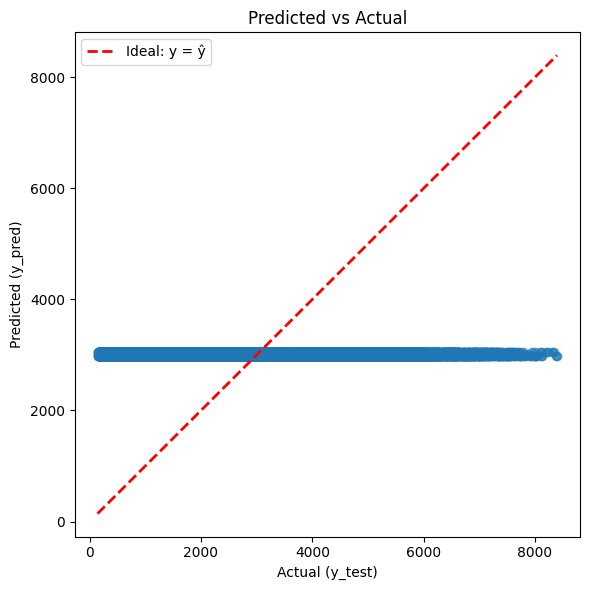

In [79]:
# 1) Predicted vs Actual
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
minv = min(np.min(y_test), np.min(y_pred))
maxv = max(np.max(y_test), np.max(y_pred))
plt.plot([minv, maxv], [minv, maxv], "r--", lw=2, label="Ideal: y = ŷ")
plt.xlabel("Actual (y_test)")
plt.ylabel("Predicted (y_pred)")
plt.title("Predicted vs Actual")
plt.legend()
plt.tight_layout()
plt.show()
